# dfc_speed - Demo Notebook

**Goal:** Validate dFC speed computation on simulated FC timeseries across 3 groups.

**Notebook structure:**
1. Imports
2. Data - simulation (active) / CSV loader (commented out)
3. Speed computation + sanity checks
4. Per-subject and group-level summaries

> Groups are parameterised by their noise level:  
> `Control (slow) < Model_A (medium) < Model_B (fast)`  
> Expected result: mean speed should increase monotonically across groups.

---

## 1. Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

# ── Path setup (adjust if running from a different directory) ──────────────
sys.path.insert(0, os.path.abspath('..'))

from dfc_speed import (
    compute_dfc_speed,
    compute_dfc_speed_batch,
    speed_summary,
    group_summary,
)

print('Imports OK')

Imports OK


## 2. Data

### 2a. Simulation (active)

Simulates sliding-window FC matrices as a **base connectivity matrix + frame-level Gaussian noise**.  
Noise level controls speed: higher noise → larger frame-to-frame distance → higher speed.

**Parameters to adjust to match your data:**
- `N` : number of brain regions (ROIs)
- `T` : number of timepoints (sliding windows)
- `S` : number of subjects per group
- `noise` per group: relative speed contrast between conditions

In [19]:
rng = np.random.default_rng(42)  # fixed seed for reproducibility

# ── Simulation parameters ─────────────────────────────────────────────────
N = 30   # number of ROIs
T = 80   # number of sliding-window timepoints
S = 12   # subjects per group

# Group labels and associated noise levels (controls speed contrast)
GROUPS = {
    'Control':  0.05,   # slow dynamics
    'Model_A':  0.10,   # medium dynamics
    'Model_B':  0.20,   # fast dynamics
}

# ── Simulation function ───────────────────────────────────────────────────
def simulate_fc_timeseries(T, N, noise, rng):
    """
    Generate one subject's FC timeseries: (T, N, N) symmetric matrices.

    Strategy: shared base matrix + independent per-frame Gaussian noise.
    The noise level directly controls frame-to-frame distance (speed).
    """
    # Base FC matrix (shared structure across frames)
    base = rng.standard_normal((N, N))
    base = (base + base.T) / 2
    np.fill_diagonal(base, 1.0)

    frames = []
    for _ in range(T):
        noise_mat = rng.standard_normal((N, N))
        frame = base + noise * noise_mat
        frame = (frame + frame.T) / 2     # keep symmetric
        np.fill_diagonal(frame, 1.0)      # unit diagonal
        frames.append(frame)

    return np.stack(frames)  # (T, N, N)


# ── Generate data for all groups ──────────────────────────────────────────
fc_data = {}   # dict: group_name -> (S, T, N, N)
for group, noise in GROUPS.items():
    fc_data[group] = np.stack([
        simulate_fc_timeseries(T, N, noise, rng)
        for _ in range(S)
    ])
    print(f"{group:10s}  shape={fc_data[group].shape}  noise={noise}")

Control     shape=(12, 80, 30, 30)  noise=0.05
Model_A     shape=(12, 80, 30, 30)  noise=0.1
Model_B     shape=(12, 80, 30, 30)  noise=0.2


### Plotting fc_data

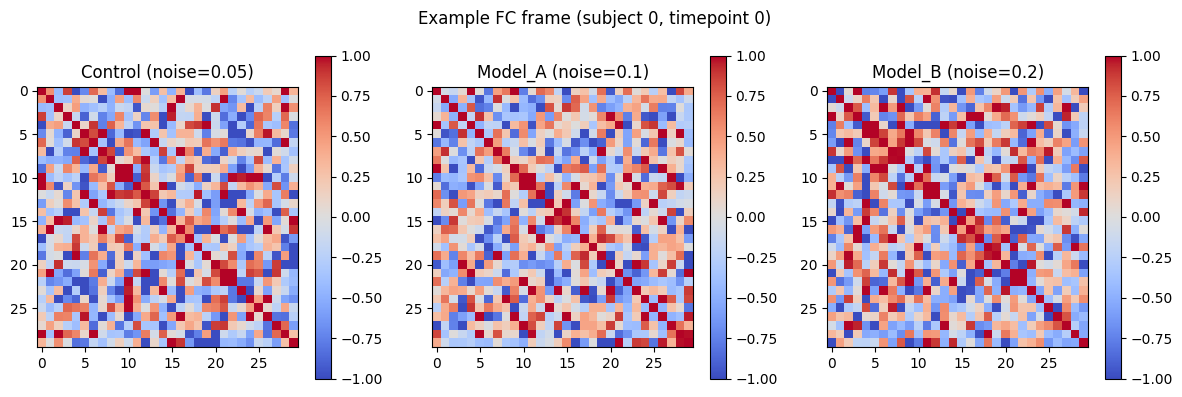

In [26]:
plt.figure(figsize=(12, 4))
for i, (group, data) in enumerate(fc_data.items()):
    plt.subplot(1, len(GROUPS), i+1)
    plt.imshow(data[0, 0], vmin=-1, vmax=1, cmap='coolwarm')
    plt.title(f"{group} (noise={GROUPS[group]})")
    plt.colorbar()
plt.suptitle("Example FC frame (subject 0, timepoint 0)")
plt.tight_layout()
plt.show()

### 2b. Load from CSV (commented out)

Use this block if your FC timeseries are stored as CSV files.

**Expected CSV format (one file per subject per group):**
```
# Rows = timepoints (T)
# Columns = upper-triangle FC values  →  N*(N-1)/2 columns
```

Adjust `N`, `data_dir`, and `group_folders` to match your file structure.

In [ ]:
# ── CSV LOADER — uncomment and adapt to use real data ─────────────────────

# import glob
#
# N = 30          # number of ROIs — must match your data
# data_dir = '../data/'
#
# group_folders = {
#     'Control': 'control/',
#     'Model_A': 'model_a/',
#     'Model_B': 'model_b/',
# }
#
# def load_fc_from_csv(filepath, N):
#     """
#     Load one subject's FC timeseries from CSV.
#     Expects: (T, n_pairs) where n_pairs = N*(N-1)/2  [upper triangle]
#     Returns: (T, N, N) array of symmetric FC matrices.
#     """
#     df = pd.read_csv(filepath, header=None)
#     T_local = len(df)
#     fc_seq = np.zeros((T_local, N, N))
#     idx = np.triu_indices(N, k=1)
#     for t in range(T_local):
#         mat = np.zeros((N, N))
#         mat[idx] = df.iloc[t].values
#         mat = mat + mat.T          # symmetrise
#         np.fill_diagonal(mat, 1.0)
#         fc_seq[t] = mat
#     return fc_seq
#
# fc_data = {}
# for group, folder in group_folders.items():
#     files = sorted(glob.glob(os.path.join(data_dir, folder, '*.csv')))
#     fc_data[group] = np.stack([load_fc_from_csv(f, N) for f in files])
#     print(f"{group:10s}  n_subjects={len(files)}  shape={fc_data[group].shape}")

## 3. Speed computation + sanity checks

**What we verify here:**
- Output shape is `(T-1,)` per subject ✓
- All speed values are non-negative ✓
- Mean speed increases across groups: `Control < Model_A < Model_B` ✓

> The monotonic ordering is guaranteed by construction in simulation.  
> Use it to confirm the function is working correctly before plugging in real data.

In [27]:
# ── Compute speed for all groups ──────────────────────────────────────────
speeds = {}   # dict: group_name -> list of (T-1,) arrays, one per subject

for group, fc_array in fc_data.items():
    # fc_array shape: (S, T, N, N)
    speeds[group] = [
        compute_dfc_speed(fc_array[s])   # returns (T-1,)
        for s in range(fc_array.shape[0])
    ]

# ── Sanity check 1: output shape ──────────────────────────────────────────
print('=== Sanity check 1: output shape ===')
for group, spd_list in speeds.items():
    expected_len = fc_data[group].shape[1] - 1   # T-1
    for s, spd in enumerate(spd_list):
        assert spd.shape == (expected_len,), \
            f"{group} subject {s}: expected ({expected_len},), got {spd.shape}"
    print(f"  {group:10s}  shape OK -> ({expected_len},) x {len(spd_list)} subjects")

# ── Sanity check 2: non-negative values ───────────────────────────────────
print('\n=== Sanity check 2: non-negative values ===')
for group, spd_list in speeds.items():
    all_vals = np.concatenate(spd_list)
    assert np.all(all_vals >= 0), f"{group}: negative speed values found!"
    print(f"  {group:10s}  min={all_vals.min():.6f}  OK")

# ── Sanity check 3: monotonic group ordering ──────────────────────────────
print('\n=== Sanity check 3: group mean speed ordering ===')
group_means = {
    g: np.mean([s.mean() for s in spd_list])
    for g, spd_list in speeds.items()
}
for group, mean_val in group_means.items():
    print(f"  {group:10s}  mean speed = {mean_val:.6f}")

means = list(group_means.values())
is_monotonic = all(means[i] < means[i+1] for i in range(len(means)-1))
print(f"\n  Monotonically increasing: {is_monotonic}  "
      f"{'PASS' if is_monotonic else 'FAIL — check noise levels or compute_dfc_speed'}")

=== Sanity check 1: output shape ===
  Control     shape OK -> (79,) x 12 subjects
  Model_A     shape OK -> (79,) x 12 subjects
  Model_B     shape OK -> (79,) x 12 subjects

=== Sanity check 2: non-negative values ===
  Control     min=0.940651  OK
  Model_A     min=1.875299  OK
  Model_B     min=3.760587  OK

=== Sanity check 3: group mean speed ordering ===
  Control     mean speed = 1.042229
  Model_A     mean speed = 2.081196
  Model_B     mean speed = 4.159684

  Monotonically increasing: True  PASS


## 4. Per-subject and group-level summaries

In [28]:
# ── Per-subject summary (subject 0 of each group) ─────────────────────────
print('=== Per-subject summary (subject 0) ===')
print(f"  {'Group':10s}  {'mean':>8s}  {'std':>8s}  {'median':>8s}  {'IQR':>8s}")
print('  ' + '-' * 50)
for group, spd_list in speeds.items():
    s = speed_summary(spd_list[0])
    print(f"  {group:10s}  {s['mean']:8.4f}  {s['std']:8.4f}  "
          f"{s['median']:8.4f}  {s['iqr']:8.4f}")

# ── Group-level summary (mean +/- SEM across subjects) ────────────────────
print('\n=== Group-level summary (mean +/- SEM across subjects) ===')
print(f"  {'Group':10s}  {'mean':>8s}  {'SEM':>8s}  {'n_subj':>6s}")
print('  ' + '-' * 38)
summary = group_summary(speeds)
for group, s in summary.items():
    print(f"  {group:10s}  {s['mean']:8.4f}  {s['sem']:8.4f}  {s['n_subjects']:6d}")

=== Per-subject summary (subject 0) ===
  Group           mean       std    median       IQR
  --------------------------------------------------
  Control       1.0534    0.0390    1.0481    0.0537
  Model_A       2.0893    0.0746    2.0909    0.1183
  Model_B       4.1644    0.1448    4.1616    0.2047

=== Group-level summary (mean +/- SEM across subjects) ===
  Group           mean       SEM  n_subj
  --------------------------------------
  Control       1.0422    0.0022      12
  Model_A       2.0812    0.0031      12
  Model_B       4.1597    0.0052      12


---
**If all 3 sanity checks pass → speed computation is correct. Ready to move to real data or group comparison.**

Next notebooks:
- `02_group_comparison.ipynb` — permutation tests, bootstrap CIs
- `03_visualisation.ipynb` — distribution plots, timecourses